# 따릉이 수요 예측 - ML Pipeline

## 1. 라이브러리 로드 및 설정

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost loaded successfully")
except ImportError:
    HAS_XGB = False
    print("[Warning] XGBoost not found -> pip install xgboost")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

XGBoost loaded successfully


In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

In [3]:
# pip install xgboost

## 2. 설정값 및 데이터 로드

In [4]:
# 설정값
DATA_DIR        = Path("../data")   # interpolated_available_YYYYMM.csv
SEASONAL_PERIOD = 24                # 일일 계절 주기 (시간 단위 → S=24)
TEST_DAYS       = 30                # 마지막 30일을 test set으로 사용
TARGET_RENT_ID  = "02171"           # 분석할 정류소 ID (정수형), 가장 수요가 많길래 이거부터 진행함
ALPHA = 1.5

In [21]:
# SARIMA/ARIMAX 결과 (01_sarima_weekday.ipynb 실행 후 채워넣기)
SARIMA_RESULTS = {
    'RMSE': 1.279,
    'MAE':  0.930,
    f'Asym.RMSE(alpha={ALPHA})': 1.378,
    'Under-pred rate(%)': 27.6,
}
ARIMAX_RESULTS = {
    'RMSE': 1.207,
    'MAE':  0.915,
    f'Asym.RMSE(alpha={ALPHA})': 1.307,
    'Under-pred rate(%)': 37.1,
}
# ARIMAX (기온만) 결과 — 01_sarima_weekday.ipynb에서 temp만 넣고 실행 후 채워넣기
ARIMAX_TEMP_RESULTS = {
    'RMSE': 1.262,  
    'MAE':  0.918,
    f'Asym.RMSE(alpha={ALPHA})': 1.364,
    'Under-pred rate(%)': 29.2,
}

In [8]:
from src.utils import (
    load_filtered_csvs, make_series,
    load_rainfall_binary, make_features_rainfall_binary,
    evaluate_ml_forecast, asymmetric_rmse,
)

df_raw = load_filtered_csvs(DATA_DIR)

# 2023~2025년만 사용
df_raw = df_raw[df_raw['datetime'].dt.year >= 2023]

series     = make_series(df_raw, str(TARGET_RENT_ID))
weather_df = load_rainfall_binary(DATA_DIR, threshold=1.0)

print(f'Station {TARGET_RENT_ID} — {len(series):,} hours')
print(f'Weather  — {len(weather_df):,} hours')

Station 02171 — 26,302 hours
Weather  — 43,824 hours


## 3. Feature Engineering

| Feature | 설명 |
|---------|------|
| hour, dayofweek, month | 시간 구조 (일/주/연간 계절성) |
| is_weekend | 주말 여부 |
| lag_1, lag_24, lag_168 | 1시간 / 1일 / 1주 전 수요 |
| rolling_mean_24, rolling_mean_168 | 최근 24시간 / 168시간 평균 |
| temp | 기온 (℃) |
| rain_binary | 강수여부 (1mm 기준 binary) |

In [9]:
df_feat = make_features_rainfall_binary(series, weather_df)
print(f'Feature matrix: {df_feat.shape}')
print(f'Features: {[c for c in df_feat.columns if c != "CNT"]}')
df_feat.head()

Feature matrix: (26134, 12)
Features: ['hour', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'temp', 'rain_binary']


,CNT,hour,dayofweek,month,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168,temp,rain_binary
2023-01-08 01:00:00,2.0,1,6,1,1,6.0,1.0,1.0,1.625000,1.297619,-1.8,0
2023-01-08 02:00:00,0.0,2,6,1,1,2.0,3.0,1.0,1.666667,1.303571,-2.0,0
2023-01-08 03:00:00,2.0,3,6,1,1,0.0,0.0,2.0,1.541667,1.297619,-2.4,0
2023-01-08 04:00:00,0.0,4,6,1,1,2.0,2.0,0.0,1.625000,1.297619,-2.8,0
2023-01-08 05:00:00,0.0,5,6,1,1,0.0,0.0,1.0,1.541667,1.297619,-3.1,0


## 4. Train / Test Split (평일 기준)

In [10]:
# Weekday only (same as SARIMA notebook)
df_weekday = df_feat[df_feat.index.dayofweek < 5]

test_hours = TEST_DAYS * 24
train_df = df_weekday.iloc[:-test_hours]
test_df  = df_weekday.iloc[-test_hours:]

FEATURE_COLS = [c for c in df_feat.columns if c != "CNT"]

X_train = train_df[FEATURE_COLS]
y_train = train_df["CNT"]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df["CNT"]

print(f"Train: {train_df.index[0]} ~ {train_df.index[-1]} ({len(train_df):,} rows)")
print(f"Test : {test_df.index[0]} ~ {test_df.index[-1]} ({len(test_df):,} rows)")
print(f"Features: {FEATURE_COLS}")

Train: 2023-01-09 00:00:00 ~ 2025-11-19 22:00:00 (17,951 rows)
Test : 2025-11-19 23:00:00 ~ 2025-12-31 22:00:00 (720 rows)
Features: ['hour', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'temp', 'rain_binary']


## 5. Random Forest
트리 기반 앙상블 모델. lag feature와 시간 피처를 활용해 비선형 패턴을 학습.


Random Forest fitting complete


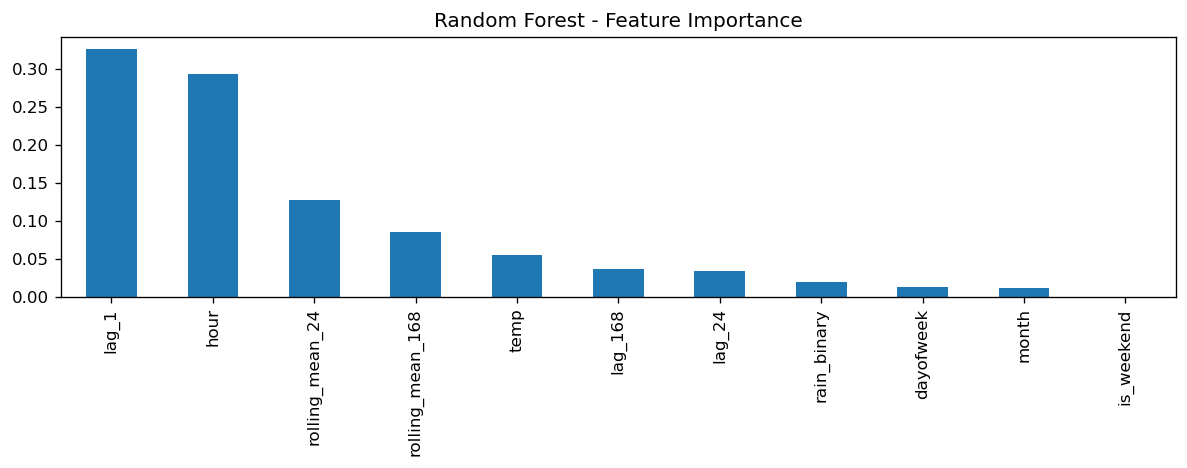

In [11]:
# Random Forest fitting
rf_model = RandomForestRegressor(
    n_estimators=200,     # 트리 개수
    max_depth=10,         # 트리 최대 깊이
    min_samples_leaf=5,   # 리프 노드 최소 샘플 수
    n_jobs=-1,            # 병렬 처리
    random_state=42,
)
rf_model = RandomForestRegressor(
    n_estimators=200,    # 트리 개수
    max_depth=10,        # 트리 최대 깊이
    min_samples_leaf=5,  # 리프 노드 최소 샘플 수
    n_jobs=-1,           # 병렬 처리
    random_state=42,
)
rf_model.fit(X_train, y_train)
print('Random Forest fitting complete')

importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(10, 4), title='Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

[Random Forest]
  RMSE            : 1.015
  MAE             : 0.759
  Asymmetric RMSE : 1.149  (alpha=1.5)
  Under-pred rate : 33.3%
  Over-pred rate : 66.7%


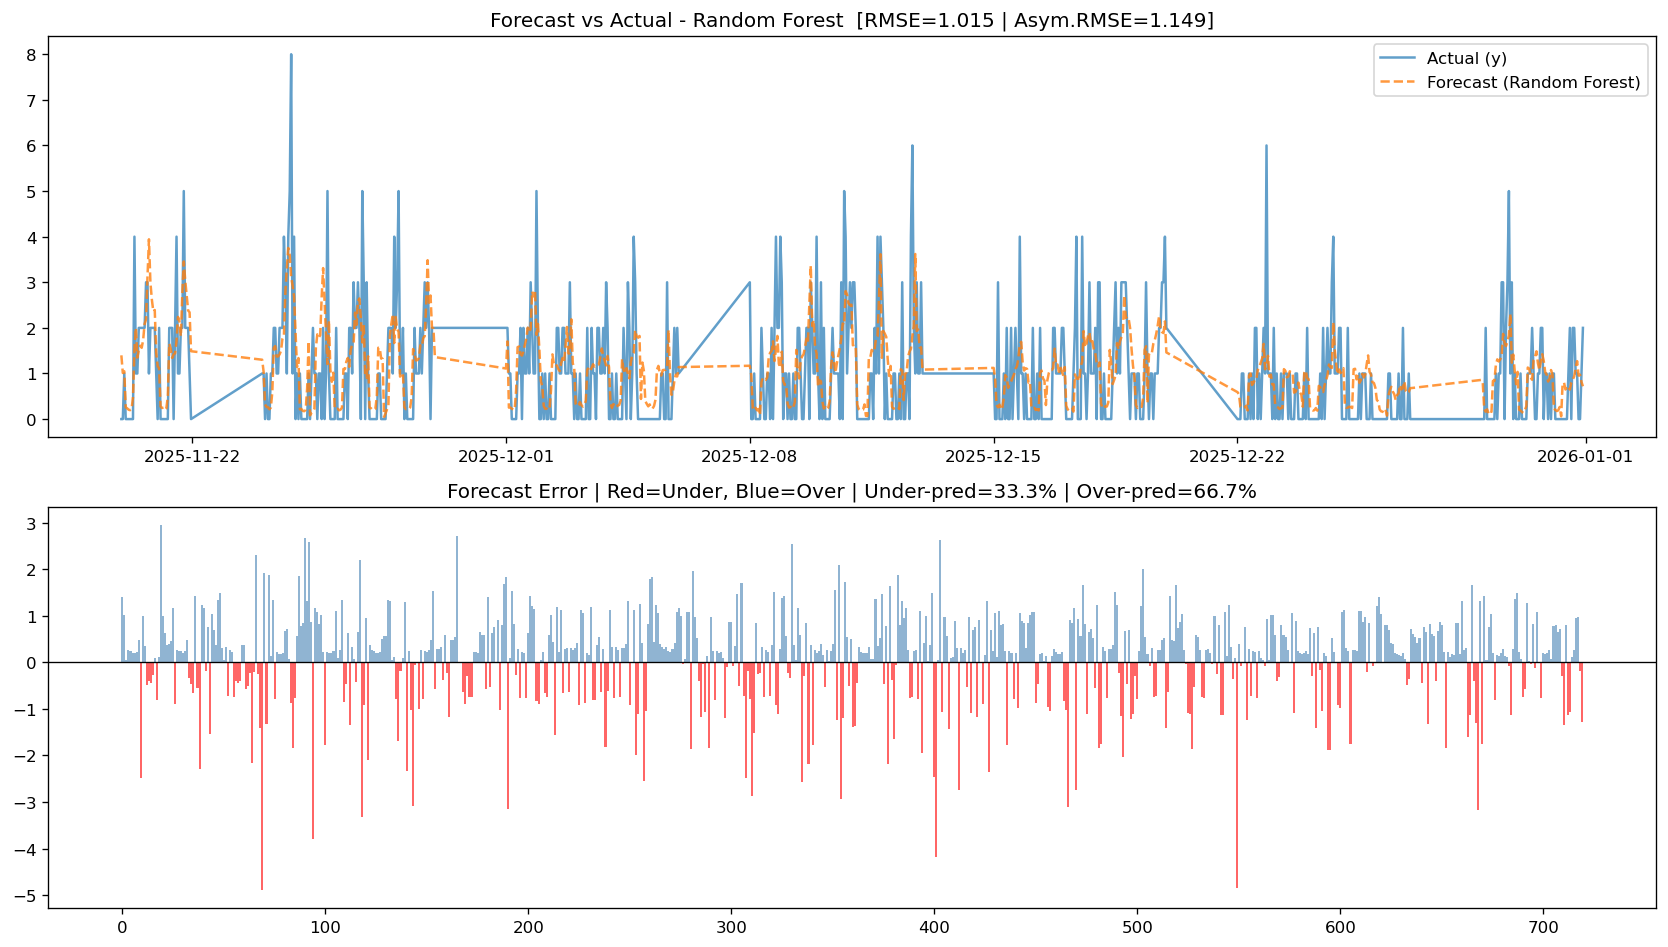

In [12]:
# Random Forest forecast evaluation
y_pred_rf = rf_model.predict(X_test)
perf_rf   = evaluate_ml_forecast(y_test, y_pred_rf,
                                  model_name="Random Forest", alpha=ALPHA)

## 7. XGBoost
Gradient Boosting 기반 모델. 순차적으로 트리를 추가해 잔차를 줄여나감.


XGBoost fitting complete

Feature Importances:
lag_1               0.229559
hour                0.220844
rain_binary         0.154361
rolling_mean_24     0.114586
lag_168             0.070001
lag_24              0.059534
rolling_mean_168    0.055660
temp                0.042606
month               0.026551
dayofweek           0.026298
is_weekend          0.000000


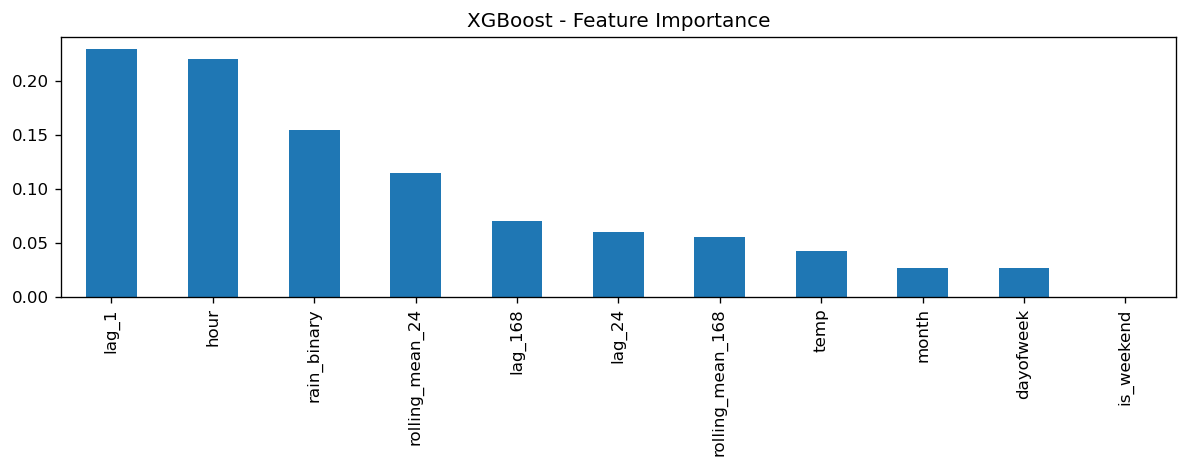

In [13]:
if HAS_XGB:
    xgb_model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )
    print("XGBoost fitting complete")

    # Feature importance
    xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
    xgb_imp = xgb_imp.sort_values(ascending=False)
    print("\nFeature Importances:")
    print(xgb_imp.to_string())

    xgb_imp.plot(kind="bar", figsize=(10, 4),
                 title="XGBoost - Feature Importance")
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost not installed. pip install xgboost")

[XGBoost]
  RMSE            : 1.005
  MAE             : 0.753
  Asymmetric RMSE : 1.138  (alpha=1.5)
  Under-pred rate : 34.0%
  Over-pred rate : 66.0%


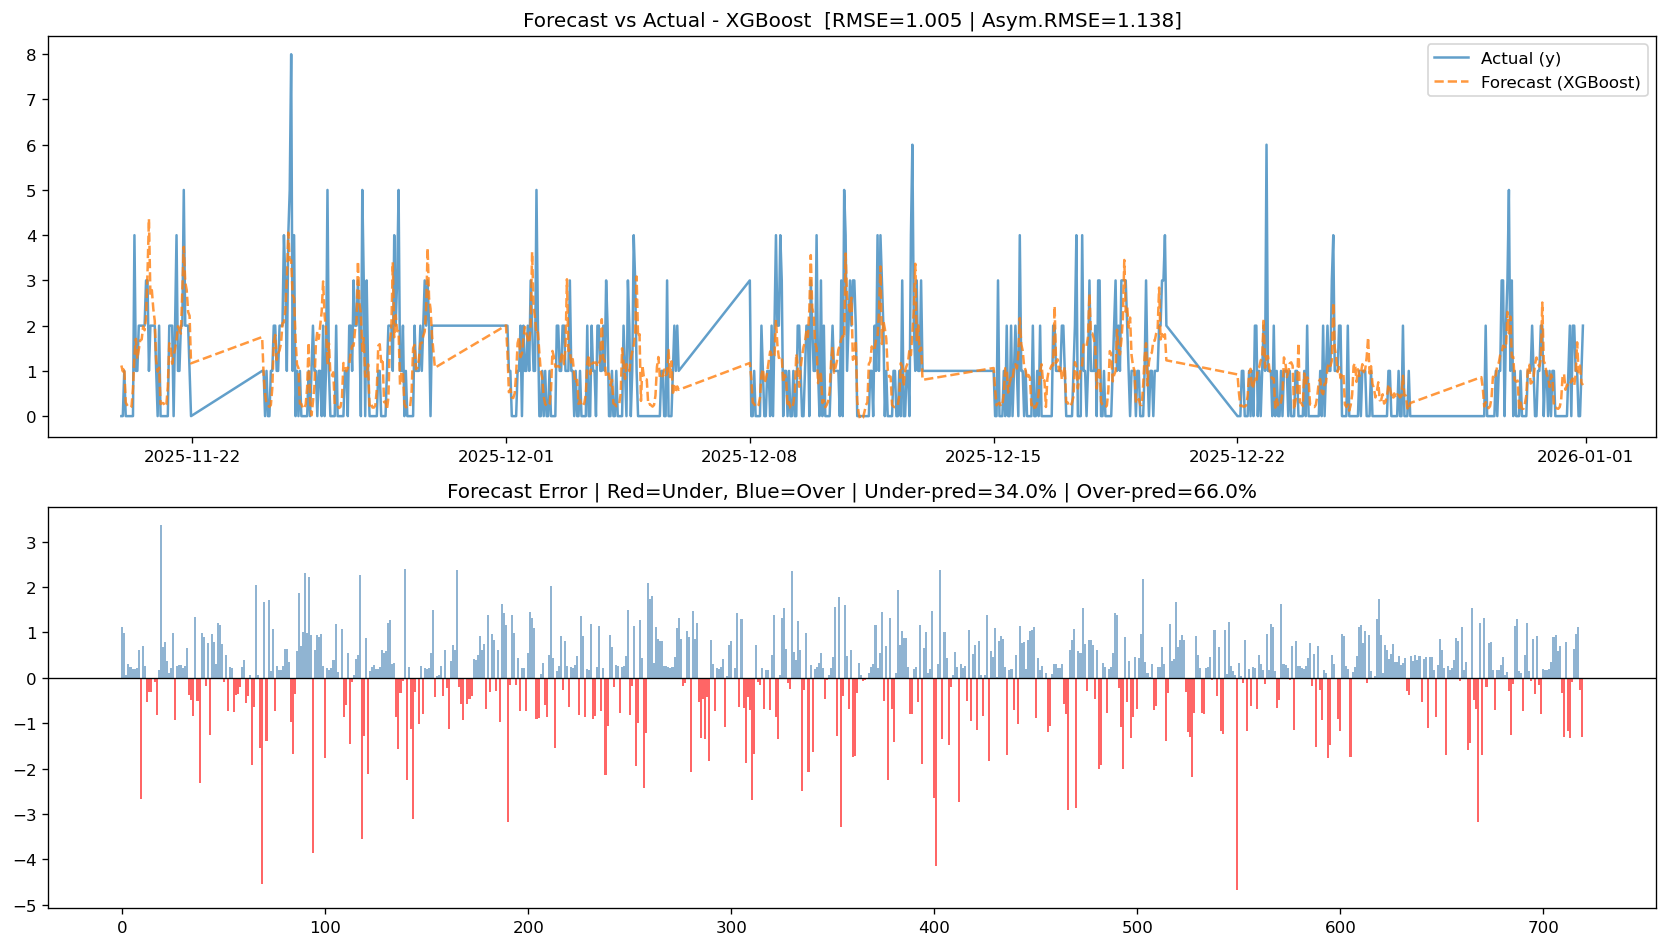

In [14]:
if HAS_XGB:
    y_pred_xgb = xgb_model.predict(X_test)
    perf_xgb   = evaluate_ml_forecast(y_test, y_pred_xgb,
                                       model_name="XGBoost", alpha=ALPHA)


## 7. XGBoost (비대칭 손실)
과소예측에 α배 패널티를 부과하는 custom objective 사용.

[XGBoost (alpha=1.5)]
  RMSE            : 1.047
  MAE             : 0.811
  Asymmetric RMSE : 1.156  (alpha=1.5)
  Under-pred rate : 30.0%
  Over-pred rate : 70.0%


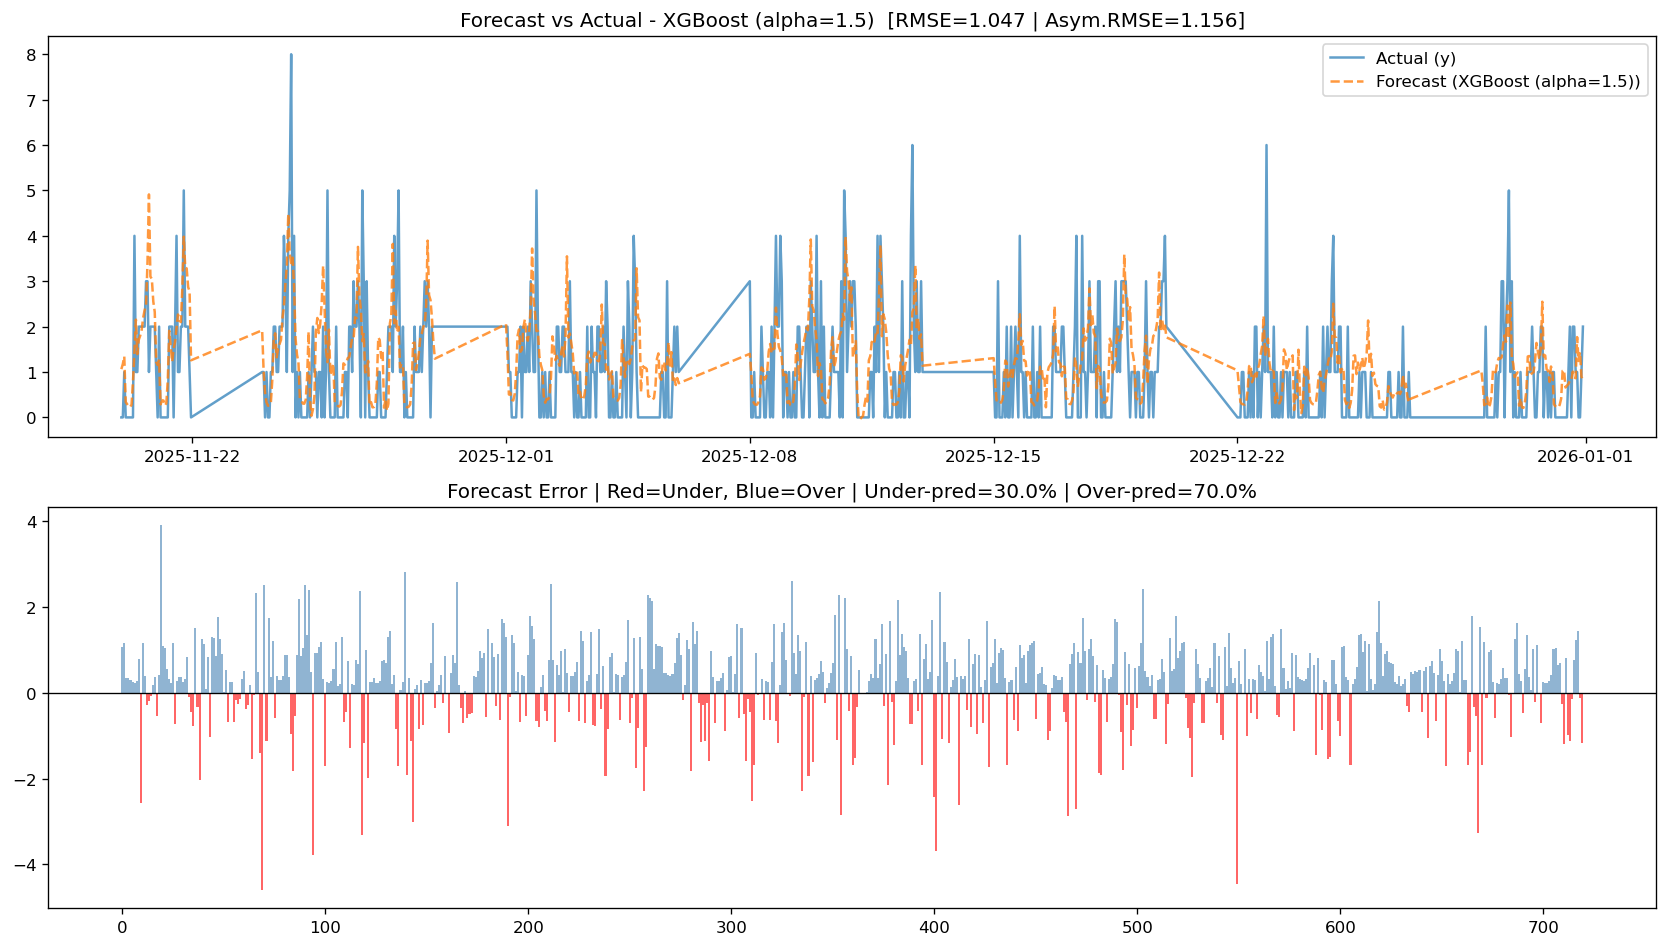

[XGBoost (alpha=2.0)]
  RMSE            : 1.093
  MAE             : 0.869
  Asymmetric RMSE : 1.267  (alpha=2.0)
  Under-pred rate : 26.5%
  Over-pred rate : 73.5%


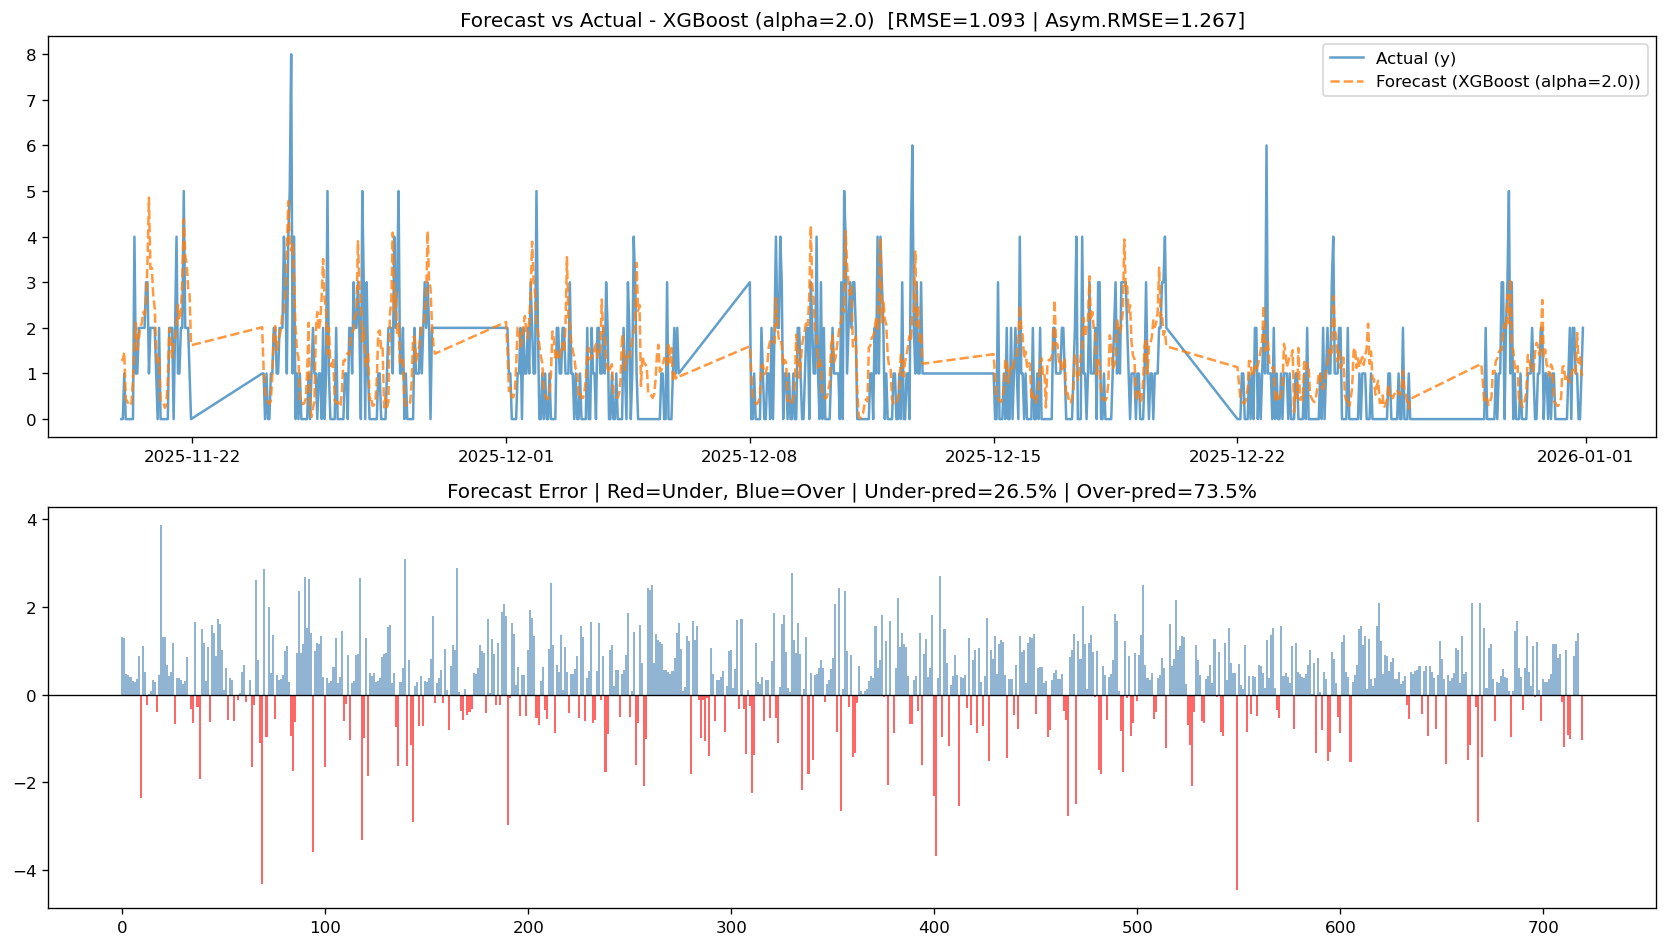

[XGBoost (alpha=3.0)]
  RMSE            : 1.159
  MAE             : 0.942
  Asymmetric RMSE : 1.422  (alpha=3.0)
  Under-pred rate : 23.5%
  Over-pred rate : 76.5%


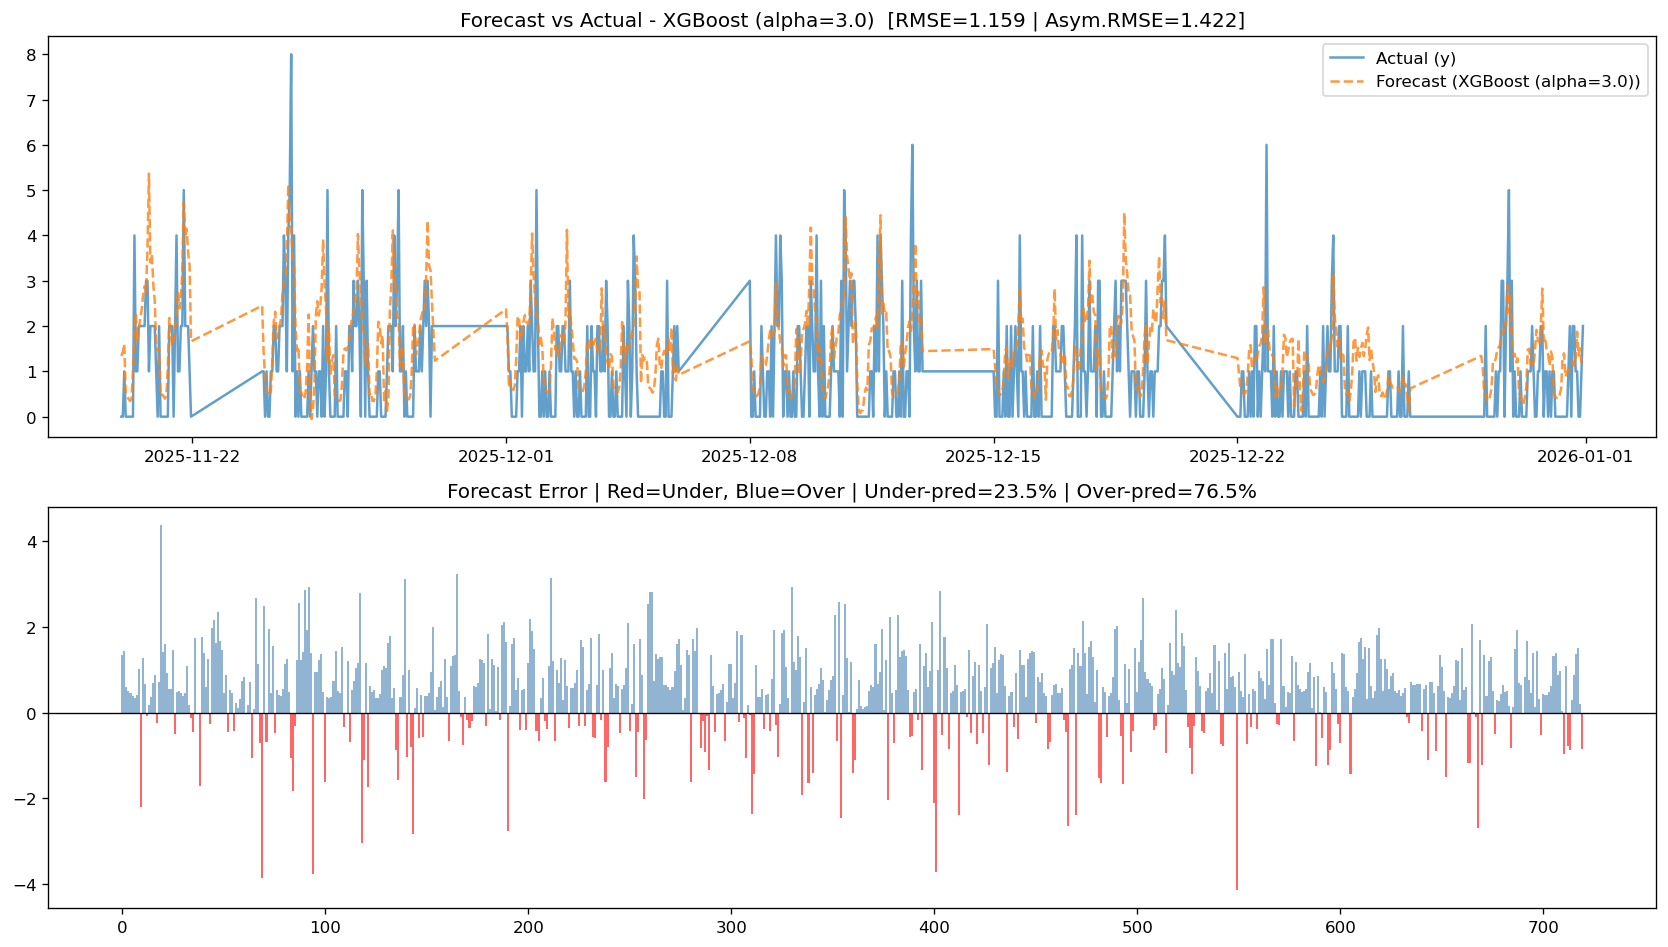

In [18]:
def asymmetric_obj(y_pred, dtrain, alpha=2.0):
    """
    Custom asymmetric loss for XGBoost.
    Under-prediction (y_pred < y_true): alpha * 2 * error
    Over-prediction  (y_pred >= y_true): 2 * error
    """
    y_true = dtrain.get_label()
    errors = y_pred - y_true
    grad = np.where(errors < 0, alpha * 2 * errors, 2 * errors)
    hess = np.where(errors < 0, alpha * 2 * np.ones_like(errors), 2 * np.ones_like(errors))
    return grad, hess

if HAS_XGB:
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest  = xgb.DMatrix(X_test,  label=y_test)
    params = {
        'max_depth': 6, 'learning_rate': 0.05,
        'subsample': 0.8, 'colsample_bytree': 0.8, 'seed': 42,
    }

    perf_xgb_asym = None
    for alpha in [1.5, 2.0, 3.0]:
        xgb_asym_model = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=300,
            obj=lambda y_pred, dtrain: asymmetric_obj(y_pred, dtrain, alpha=alpha),
            verbose_eval=False,
        )
        y_pred = xgb_asym_model.predict(dtest)
        perf   = evaluate_ml_forecast(y_test, y_pred,
                                      model_name=f'XGBoost (alpha={alpha})',
                                      alpha=alpha)
        if alpha == 1.5:
            perf_xgb_asym = perf  # alpha=1.5 결과를 대표값으로 저장

## 8. Model Comparison (SARIMA / ARIMAX / RF / XGBoost)


              Model Performance Comparison
                      RMSE    MAE  Asym.RMSE(alpha=1.5)  Under-pred rate(%)  Over-pred rate(%)
model                                                                                         
SARIMA               1.279  0.930                 1.378                27.6                NaN
ARIMAX (temp+rain)   1.207  0.915                 1.307                37.1                NaN
ARIMAX (temp only)   1.262  0.918                 1.364                29.2                NaN
Random Forest        1.015  0.759                 1.149                33.3               66.7
XGBoost              1.005  0.753                 1.138                34.0               66.0
XGBoost (alpha=1.5)  1.047  0.811                 1.156                30.0               70.0


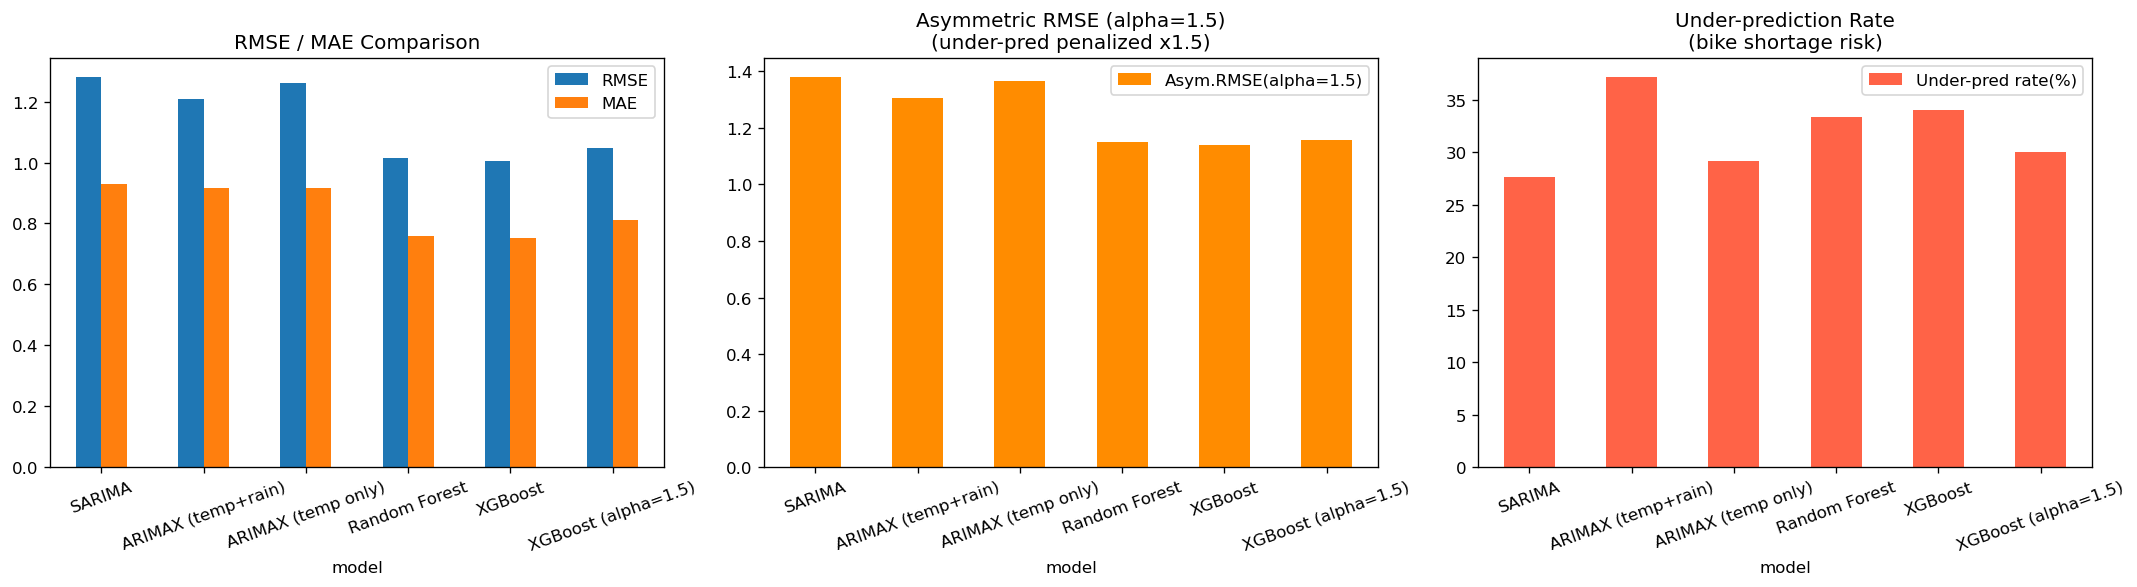

In [22]:
all_results = [
    {'model': 'SARIMA',        **SARIMA_RESULTS},
    {'model': 'ARIMAX (temp+rain)', **ARIMAX_RESULTS},
    {'model': 'ARIMAX (temp only)', **ARIMAX_TEMP_RESULTS},
    perf_rf,
    perf_xgb,
]
if perf_xgb_asym is not None:
    all_results.append(perf_xgb_asym)

result_df = pd.DataFrame(all_results).set_index('model')
print('\n' + '='*65)
print('              Model Performance Comparison')
print('='*65)
print(result_df.to_string())

asym_col = f'Asym.RMSE(alpha={ALPHA})'
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

result_df[['RMSE', 'MAE']].plot(kind='bar', ax=axes[0],
    title='RMSE / MAE Comparison', rot=20)
result_df[[asym_col]].plot(kind='bar', ax=axes[1], color='darkorange',
    title=f'Asymmetric RMSE (alpha={ALPHA})\n(under-pred penalized x{ALPHA})', rot=20)
result_df[['Under-pred rate(%)']].plot(kind='bar', ax=axes[2], color='tomato',
    title='Under-prediction Rate\n(bike shortage risk)', rot=20)

plt.tight_layout()
plt.show()
